# Hallucination Detection Baseline Evaluation

This notebook evaluates two baseline methods for detecting hallucinations in tool-augmented LLM responses using the dataset generated in `dataset_generation.ipynb`.

**Data mapping:**
- **Question** → `query` (user's original request)
- **Context** → `context` (tool API output + available tools list)
- **Answer** → `output` (model's final natural-language response)

**Methods evaluated:**
1. **LettuceDetect** ([arXiv:2502.17125](https://arxiv.org/pdf/2502.17125)) — ModernBERT-based token classification model trained to label hallucinated spans in the answer.
2. **LookBackLens** ([arXiv:2407.07071](https://arxiv.org/abs/2407.07071)) — Measures the *lookback ratio* (how much attention the LLM pays to the context vs. its own prior generated tokens) as a hallucination signal, then applies a classifier on those ratios.

**Expected output (as shown in the assignment):**
```
Question: Help me check the weather in Beijing
Context: {weather: "rainy"}
Answer: The weather is sunny.

Token probabilities: The [0.01] weather [0.01] is [0.02] sunny [0.95] . [0.01]
```

In [57]:
# Install additional packages not yet in the environment
%pip install lettucedetect scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Load Dataset

In [58]:
import json
dataset = []
with open("hallucinations_dataset.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            dataset.append(json.loads(line))

print(f"Loaded {len(dataset)} samples")
print("\nFields per sample:", list(dataset[0].keys()))
print(f"\n--- Example sample ---")
print(f"Query:   {dataset[0]['query'][:120]}...")
print(f"Context: {dataset[0]['context'][:120]}...")
print(f"Output:  {dataset[0]['output'][:120]}...")

Loaded 1034 samples

Fields per sample: ['query', 'context', 'output', 'hallucination_labels']

--- Example sample ---
Query:   I'm considering investing and I'd like to know what's happening in the market right now. Could you get me the top market...
Context: Market Trends API: {"trends": [{"name": "S&P 500", "description": "Standard & Poor's 500 Index is a market-capitalizatio...
Output:  Here are the top Market Trends in the US right now:

1. **S&P 500**: The Standard & Poor's 500 Index is a market-capital...


---
## 2. LettuceDetect

**LettuceDetect** (KR Labs, 2025) is a token-classification model built on ModernBERT. Given a (question, context, answer) triple it assigns each answer token a hallucination probability.

- **Model**: `KRLabsOrg/lettuce-detect-base-v2` (or `-large-v2`)
- **Input**: question, list of context passages, answer
- **Output**: per-token hallucination scores + hallucinated spans

Reference: https://arxiv.org/pdf/2502.17125

In [59]:
from lettucedetect.models.inference import HallucinationDetector

MODEL_PATH = "KRLabsOrg/lettucedect-base-modernbert-en-v1"

print(f"Loading LettuceDetect model: {MODEL_PATH} ...")
lettuce_detector = HallucinationDetector(
    method="transformer",
    model_path=MODEL_PATH,
)
print("Model loaded.")

Loading LettuceDetect model: KRLabsOrg/lettucedect-base-modernbert-en-v1 ...


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Model loaded.


### 2.1 Single-sample walkthrough

In [60]:
sample = dataset[0]

# --- Span-level predictions ---
span_preds = lettuce_detector.predict(
    context=[sample["context"]],
    question=sample["query"],
    answer=sample["output"],
    output_format="spans",
)

print("=== LettuceDetect — Example ===")
print(f"Question : {sample['query'][:100]}...")
print(f"Context  : {sample['context'][:100]}...")
print(f"Answer   : {sample['output'][:200]}...")
print()
if span_preds:
    print("Hallucinated spans detected:")
    for sp in span_preds:
        print(f"  Span: '{sp['span']}' | Score: {sp['score']:.4f}")
else:
    print("No hallucinated spans detected.")

=== LettuceDetect — Example ===
Question : I'm considering investing and I'd like to know what's happening in the market right now. Could you g...
Context  : Market Trends API: {"trends": [{"name": "S&P 500", "description": "Standard & Poor's 500 Index is a ...
Answer   : Here are the top Market Trends in the US right now:

1. **S&P 500**: The Standard & Poor's 500 Index is a market-capitalization-weighted index of the 500 largest U.S. publicly traded companies. Its cu...

No hallucinated spans detected.


In [64]:
# --- Token-level predictions (matches the required output format) ---
token_preds = lettuce_detector.predict(
    context=[sample["context"]],
    question=sample["query"],
    answer=sample["output"],
    output_format="tokens",
)

def format_token_probabilities(token_preds, max_tokens: int = 40) -> str:
    """Format token predictions as: The [0.01] weather [0.01] is [0.02] ..."""
    parts = []
    for tp in token_preds[:max_tokens]:
        token = tp.get("token", tp.get("word", "?"))
        score = tp.get("score", tp.get("hallucination_score", tp.get("probability", 0.0)))
        parts.append(f"{token} [{score:.2f}]")
    suffix = " ..." if len(token_preds) > max_tokens else ""
    return "Token probabilities: " + " ".join(parts) + suffix

print(format_token_probabilities(token_preds))

Token probabilities: Here [0.00]  are [0.00]  the [0.00]  top [0.00]  Market [0.00]  T [0.00] rends [0.00]  in [0.00]  the [0.00]  US [0.00]  right [0.00]  now [0.00] : [0.00] 
 [0.00] 
 [0.00] 1 [0.00] . [0.00]  ** [0.00] S [0.00] & [0.00] P [0.00]  500 [0.00] **: [0.00]  The [0.00]  Standard [0.00]  & [0.00]  Poor [0.00] 's [0.00]  500 [0.00]  Index [0.00]  is [0.00]  a [0.00]  market [0.00] - [0.00] capital [0.00] ization [0.00] - [0.00] weighted [0.00]  index [0.00]  of [0.00] ...


### 2.2 Batch evaluation

In [65]:
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np


EVAL_SIZE = 100  # Increase to len(dataset) to evaluate the full set

lettuce_results = []
for item in tqdm(dataset[:EVAL_SIZE], desc="LettuceDetect"):
    try:
        spans = lettuce_detector.predict(
            context=[item["context"]],
            question=item["query"],
            answer=item["output"],
            output_format="spans",
        )
        max_score = max((s["score"] for s in spans), default=0.0)
        lettuce_results.append({
            "query": item["query"][:60] + "...",
            "predicted_hallucination": len(spans) > 0,
            "max_hallucination_score": max_score,
            "num_hallucinated_spans": len(spans),
            "spans": spans,
        })
    except Exception as exc:
        lettuce_results.append({
            "query": item["query"][:60] + "...",
            "predicted_hallucination": False,
            "max_hallucination_score": 0.0,
            "num_hallucinated_spans": 0,
            "spans": [],
            "error": str(exc),
        })

n_hall = sum(r["predicted_hallucination"] for r in lettuce_results)
mean_score = np.mean([r["max_hallucination_score"] for r in lettuce_results])
print(f"\nResults on {EVAL_SIZE} samples:")
print(f"  Flagged as hallucinated : {n_hall}/{EVAL_SIZE} ({n_hall/EVAL_SIZE:.1%})")
print(f"  Mean max halluc. score  : {mean_score:.4f}")

LettuceDetect:   0%|          | 0/100 [00:00<?, ?it/s]


Results on 100 samples:
  Flagged as hallucinated : 0/100 (0.0%)
  Mean max halluc. score  : 0.0000


In [66]:
df_lettuce = pd.DataFrame([
    {
        "query": r["query"],
        "hallucination_detected": r["predicted_hallucination"],
        "max_score": r["max_hallucination_score"],
        "num_spans": r["num_hallucinated_spans"],
    }
    for r in lettuce_results
])
display(df_lettuce.head(10))
print("\nValue counts — hallucination_detected:")
display(df_lettuce["hallucination_detected"].value_counts())

,query,hallucination_detected,max_score,num_spans
0,I'm considering investing and I'd like to know...,False,0.0,0
1,"Could you please find me some quotes about ""in...",False,0.0,0
2,Can you dig up some juicy details about the zi...,False,0.0,0
3,"Hey, can you show me the list of football comp...",False,0.0,0
4,I'd like to see this in practice! Can you fetc...,False,0.0,0
5,Could you provide me with a list of upcoming A...,False,0.0,0
6,Could you tell me what languages are commonly ...,False,0.0,0
7,It's fascinating how languages shape our commu...,False,0.0,0
8,Can you generate a unique and memorable passwo...,False,0.0,0
9,"That's interesting. Now, I have a personal quo...",False,0.0,0



Value counts — hallucination_detected:


hallucination_detected
False    100
Name: count, dtype: int64

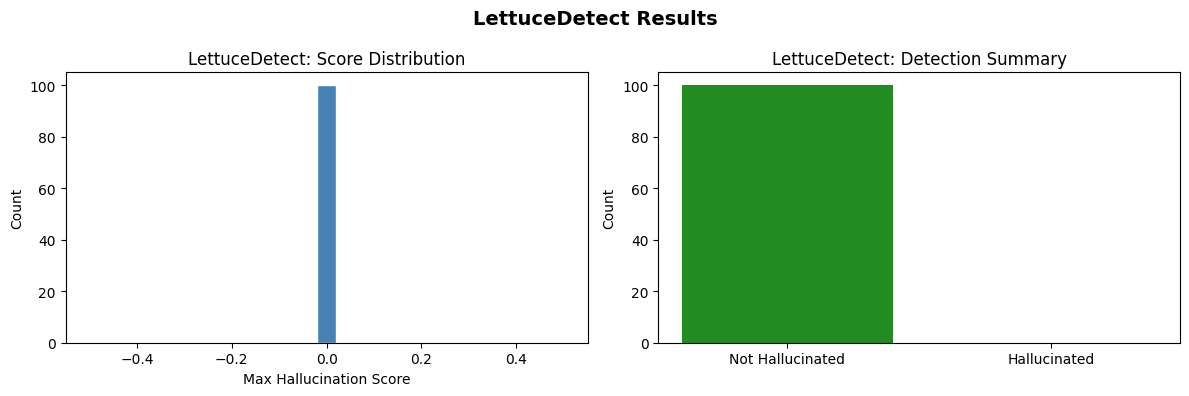

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_lettuce["max_score"], bins=25, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Max Hallucination Score")
axes[0].set_ylabel("Count")
axes[0].set_title("LettuceDetect: Score Distribution")

counts = df_lettuce["hallucination_detected"].value_counts()
axes[1].bar(["Not Hallucinated", "Hallucinated"],
            [counts.get(False, 0), counts.get(True, 0)],
            color=["forestgreen", "tomato"])
axes[1].set_ylabel("Count")
axes[1].set_title("LettuceDetect: Detection Summary")

plt.suptitle("LettuceDetect Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. LookBackLens

**LookBackLens** (Tang et al., 2024) uses the *lookback ratio* as a hallucination signal. For each answer token at position $t$:

$$\text{LookbackRatio}(t) = \frac{\sum_{k < |\text{context}|} A_{t,k}}{\sum_{k < |\text{context}|} A_{t,k} \;+\; \sum_{|\text{context}| \le k < t} A_{t,k}}$$

where $A_{t,k}$ is the averaged attention weight from the token at position $t$ to position $k$ (averaged over all layers and heads).

- **High ratio** → the model is attending to the provided context → likely grounded
- **Low ratio** → the model is attending to its own prior generation → potential hallucination

The original paper trains a linear classifier on per-layer/per-head lookback ratio vectors using Llama-2-7B. Below we implement the core algorithm for **GPT-2** (accessible without large-model downloads) and use a simple logistic-regression classifier trained on aggregate ratio features. To reproduce the paper's exact numbers, replace `MODEL_NAME` with `meta-llama/Llama-2-7b-chat-hf` and provide the paper's pre-trained classifier weights.

Reference: https://arxiv.org/abs/2407.07071 | Code: https://github.com/amazon-science/lookback-lens

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Swap with a larger model for results closer to the original paper.
# The original paper uses meta-llama/Llama-2-7b-chat-hf.
MODEL_NAME =  "gpt2" # or "meta-llama/Llama-2-7b-chat-hf"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading model '{MODEL_NAME}' for LookBackLens ...")
lbl_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Always use float32 for GPT-2: it was trained in fp32 and fp16 causes
# NaN/inf in the attention softmax on CUDA, which crashes the kernel.
# attn_implementation="eager" is required so that output_attentions=True
# actually returns attention tensors — SDPA (the new default) silently
# drops them, leaving outputs.attentions as an empty tuple.
lbl_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32,
    attn_implementation="eager",
).to(DEVICE)
lbl_model.eval()

if lbl_tokenizer.pad_token is None:
    lbl_tokenizer.pad_token = lbl_tokenizer.eos_token

print(f"Model loaded on {DEVICE}.")
print(f"  Layers : {lbl_model.config.n_layer}")
print(f"  Heads  : {lbl_model.config.n_head}")

Loading model 'gpt2' for LookBackLens ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded on cpu.
  Layers : 12
  Heads  : 12


In [69]:
def compute_lookback_ratios(
    model,
    tokenizer,
    context: str,
    answer: str,
    max_context_tokens: int = 200,
    max_answer_tokens: int = 100,
) -> list:
    """
    Compute per-token lookback ratios for `answer` given `context`.

    Returns a list of dicts:
      { 'token': str,
        'lookback_ratio': float,   # high = grounded, low = potential hallucination
        'attn_to_context': float,
        'attn_to_generated': float }
    """
    ctx_ids = tokenizer.encode(
        context, add_special_tokens=True, truncation=True, max_length=max_context_tokens
    )
    ans_ids = tokenizer.encode(
        answer, add_special_tokens=False, truncation=True, max_length=max_answer_tokens
    )
    if not ans_ids:
        return []

    context_len = len(ctx_ids)
    full_ids = ctx_ids + ans_ids
    input_ids = torch.tensor([full_ids], dtype=torch.long).to(model.device)

    with torch.no_grad():
        outputs = model(input_ids, output_attentions=True)

    # Accumulate average attention incrementally to avoid allocating a
    # (n_layers, seq, seq) tensor — reduces peak GPU memory.
    # Each layer: (1, n_heads, seq, seq) → mean over heads → (seq, seq)
    n_layers = len(outputs.attentions)
    avg_attn = outputs.attentions[0][0].mean(0)          # (seq, seq) fp32
    for layer_attn in outputs.attentions[1:]:
        avg_attn = avg_attn + layer_attn[0].mean(0)
    avg_attn = (avg_attn / n_layers).cpu()

    # Free GPU memory before the Python loop
    del outputs
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    answer_tokens = tokenizer.convert_ids_to_tokens(ans_ids)
    total_len = len(full_ids)
    ratios = []

    for offset, t in enumerate(range(context_len, total_len)):
        row = avg_attn[t, : t + 1]          # causal: only attend to positions ≤ t

        attn_ctx = row[:context_len].sum().item()
        attn_gen = row[context_len:t].sum().item()   # prior answer tokens only

        denom = attn_ctx + attn_gen
        ratio = (attn_ctx / denom) if denom > 1e-9 else 0.5

        token_str = answer_tokens[offset] if offset < len(answer_tokens) else "<unk>"
        ratios.append({
            "token": token_str,
            "lookback_ratio": ratio,
            "attn_to_context": attn_ctx,
            "attn_to_generated": attn_gen,
        })

    return ratios


def aggregate_lookback_features(ratios: list) -> dict:
    """
    Aggregate per-token ratios into sample-level features for the classifier.
    Mirrors the feature engineering in the original LookBackLens paper.
    """
    if not ratios:
        return {"mean_ratio": 0.5, "min_ratio": 0.5, "frac_low": 0.0, "std_ratio": 0.0}

    vals = np.array([r["lookback_ratio"] for r in ratios])
    return {
        "mean_ratio": float(vals.mean()),
        "min_ratio": float(vals.min()),
        "frac_low": float((vals < 0.3).mean()),   # fraction of "distracted" tokens
        "std_ratio": float(vals.std()),
    }


print("LookBackLens helper functions defined.")

LookBackLens helper functions defined.


### 3.1 Single-sample walkthrough

In [70]:
sample = dataset[0]
context_input = f"Question: {sample['query']}\nContext: {sample['context']}"

print("Computing lookback ratios for example sample ...")
ratios = compute_lookback_ratios(
    lbl_model, lbl_tokenizer,
    context=context_input,
    answer=sample["output"],
)

print("\n=== LookBackLens — Example ===")
print(f"Question : {sample['query'][:100]}...")
print(f"Context  : {sample['context'][:100]}...")
print(f"Answer   : {sample['output'][:200]}...")
print()
print(f"{'Token':<22} {'LookbackRatio':>14} {'Attn→Ctx':>12} {'Attn→Gen':>12}")
print("-" * 64)
for r in ratios[:25]:
    print(f"{r['token']:<22} {r['lookback_ratio']:>14.4f} {r['attn_to_context']:>12.4f} {r['attn_to_generated']:>12.4f}")

feats = aggregate_lookback_features(ratios)
print(f"\nAggregate features:")
for k, v in feats.items():
    print(f"  {k:<25} {v:.4f}")

Computing lookback ratios for example sample ...



=== LookBackLens — Example ===
Question : I'm considering investing and I'd like to know what's happening in the market right now. Could you g...
Context  : Market Trends API: {"trends": [{"name": "S&P 500", "description": "Standard & Poor's 500 Index is a ...
Answer   : Here are the top Market Trends in the US right now:

1. **S&P 500**: The Standard & Poor's 500 Index is a market-capitalization-weighted index of the 500 largest U.S. publicly traded companies. Its cu...

Token                   LookbackRatio     Attn→Ctx     Attn→Gen
----------------------------------------------------------------
Here                           1.0000       0.9291       0.0000
Ġare                           0.8839       0.8245       0.1083
Ġthe                           0.8336       0.7904       0.1577
Ġtop                           0.8104       0.7539       0.1764
ĠMarket                        0.8011       0.7573       0.1880
ĠTrends                        0.7301       0.6732       0.2489
Ġin      

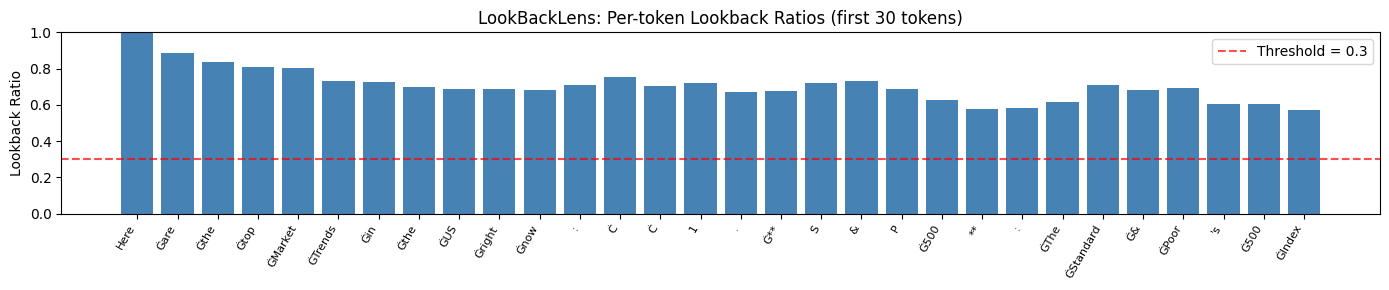

Red bars (ratio < 0.3) = token is mainly attending to prior generated text → potential hallucination signal.


In [71]:
# Visualise lookback ratios for the first sample
tokens_plot = [r["token"] for r in ratios[:30]]
ratio_vals = [r["lookback_ratio"] for r in ratios[:30]]

fig, ax = plt.subplots(figsize=(14, 3))
colors = ["tomato" if v < 0.3 else "steelblue" for v in ratio_vals]
ax.bar(range(len(tokens_plot)), ratio_vals, color=colors)
ax.axhline(0.3, color="red", linestyle="--", alpha=0.7, label="Threshold = 0.3")
ax.set_xticks(range(len(tokens_plot)))
ax.set_xticklabels(tokens_plot, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Lookback Ratio")
ax.set_title("LookBackLens: Per-token Lookback Ratios (first 30 tokens)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()
print("Red bars (ratio < 0.3) = token is mainly attending to prior generated text → potential hallucination signal.")

### 3.2 Batch evaluation

We collect lookback-ratio features for all samples, then fit a **logistic-regression classifier** on those features. Because our dataset does not currently contain ground-truth hallucination labels (the corruption step was not applied in `dataset_generation.ipynb`), we also report *unsupervised* thresholding results alongside the classifier output.

In [72]:
LBL_EVAL_SIZE = 100  # Increase for larger evaluation

lbl_raw_results = []   # per-sample token-level ratios
lbl_features = []      # per-sample aggregate feature dicts

for item in tqdm(dataset[:LBL_EVAL_SIZE], desc="LookBackLens"):
    context_input = f"Question: {item['query']}\nContext: {item['context']}"
    try:
        ratios = compute_lookback_ratios(
            lbl_model, lbl_tokenizer,
            context=context_input,
            answer=item["output"],
        )
        feats = aggregate_lookback_features(ratios)
    except Exception as exc:
        ratios = []
        feats = {"mean_ratio": 0.5, "min_ratio": 0.5, "frac_low": 0.0, "std_ratio": 0.0, "error": str(exc)}

    lbl_raw_results.append({
        "query": item["query"][:60] + "...",
        "ratios": ratios,
    })
    lbl_features.append(feats)

print(f"Feature extraction complete for {LBL_EVAL_SIZE} samples.")

LookBackLens:   0%|          | 0/100 [00:00<?, ?it/s]

Feature extraction complete for 100 samples.


In [73]:
# ── Unsupervised threshold classifier ──────────────────────────────────────────
# Following the paper's intuition: low average lookback ratio → hallucination.
THRESHOLD = 0.3

lbl_results = []
for raw, feats in zip(lbl_raw_results, lbl_features):
    mean_r = feats["mean_ratio"]
    lbl_results.append({
        "query": raw["query"],
        "predicted_hallucination_threshold": mean_r < THRESHOLD,
        "mean_lookback_ratio": mean_r,
        "min_lookback_ratio": feats["min_ratio"],
        "frac_low_ratio": feats["frac_low"],
        "std_lookback_ratio": feats["std_ratio"],
    })

n_hall_lbl = sum(r["predicted_hallucination_threshold"] for r in lbl_results)
print(f"LookBackLens (threshold={THRESHOLD}) on {LBL_EVAL_SIZE} samples:")
print(f"  Flagged as hallucinated : {n_hall_lbl}/{LBL_EVAL_SIZE} ({n_hall_lbl/LBL_EVAL_SIZE:.1%})")
print(f"  Mean lookback ratio     : {np.mean([r['mean_lookback_ratio'] for r in lbl_results]):.4f}")

LookBackLens (threshold=0.3) on 100 samples:
  Flagged as hallucinated : 0/100 (0.0%)
  Mean lookback ratio     : 0.6168


In [74]:
# ── Logistic Regression classifier (unsupervised proxy labels for demo) ────────
# In the original paper a classifier is trained on labelled hallucination data.
# Here we use the threshold-based labels as proxy for demonstration.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

X = np.array([[f["mean_ratio"], f["min_ratio"], f["frac_low"], f["std_ratio"]] for f in lbl_features])
y_proxy = np.array([1 if r["predicted_hallucination_threshold"] else 0 for r in lbl_results])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = LogisticRegression(random_state=42, max_iter=500)

if y_proxy.sum() > 1 and (len(y_proxy) - y_proxy.sum()) > 1:
    cv_acc = cross_val_score(clf, X_scaled, y_proxy, cv=5, scoring="accuracy")
    print(f"Logistic Regression 5-fold CV accuracy (on proxy labels): {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
    clf.fit(X_scaled, y_proxy)
    y_pred_lr = clf.predict(X_scaled)
    print(f"Feature coefficients: mean_ratio={clf.coef_[0,0]:.3f}, min_ratio={clf.coef_[0,1]:.3f}, frac_low={clf.coef_[0,2]:.3f}, std_ratio={clf.coef_[0,3]:.3f}")
else:
    print("Not enough positive/negative samples for cross-validation — reporting threshold results only.")
    clf = None

Not enough positive/negative samples for cross-validation — reporting threshold results only.


In [75]:
df_lbl = pd.DataFrame(lbl_results)
display(df_lbl.head(10))
print("\nValue counts — predicted_hallucination_threshold:")
display(df_lbl["predicted_hallucination_threshold"].value_counts())

,query,predicted_hallucination_threshold,mean_lookback_ratio,min_lookback_ratio,frac_low_ratio,std_lookback_ratio
0,I'm considering investing and I'd like to know...,False,0.621908,0.487959,0.0,0.084082
1,"Could you please find me some quotes about ""in...",False,0.643557,0.495199,0.0,0.072778
2,Can you dig up some juicy details about the zi...,False,0.600685,0.406987,0.0,0.101974
3,"Hey, can you show me the list of football comp...",False,0.584544,0.433945,0.0,0.106691
4,I'd like to see this in practice! Can you fetc...,False,0.649651,0.567997,0.0,0.062867
5,Could you provide me with a list of upcoming A...,False,0.577614,0.452701,0.0,0.101024
6,Could you tell me what languages are commonly ...,False,0.714078,0.595630,0.0,0.085257
7,It's fascinating how languages shape our commu...,False,0.594948,0.372283,0.0,0.109732
8,Can you generate a unique and memorable passwo...,False,0.673994,0.557896,0.0,0.089238
9,"That's interesting. Now, I have a personal quo...",False,0.645810,0.450732,0.0,0.098993



Value counts — predicted_hallucination_threshold:


predicted_hallucination_threshold
False    100
Name: count, dtype: int64

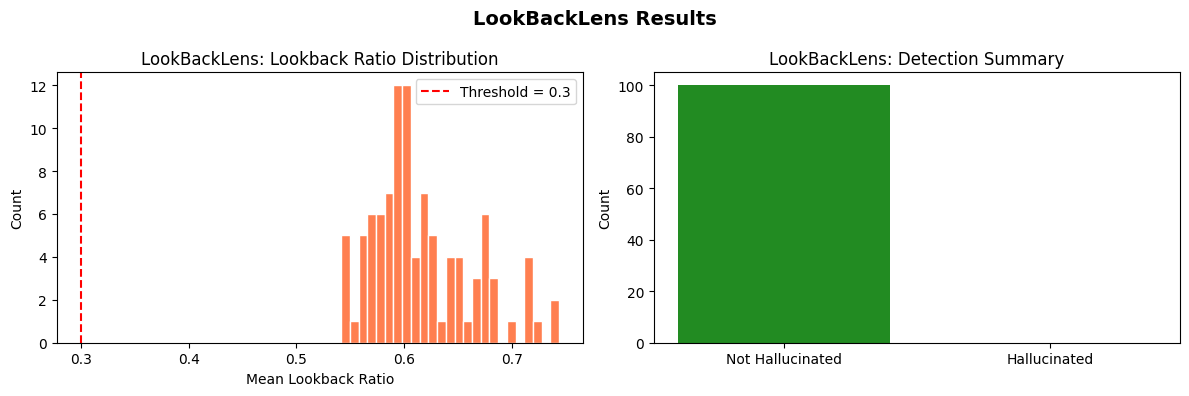

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_lbl["mean_lookback_ratio"], bins=25, color="coral", edgecolor="white")
axes[0].axvline(THRESHOLD, color="red", linestyle="--", label=f"Threshold = {THRESHOLD}")
axes[0].set_xlabel("Mean Lookback Ratio")
axes[0].set_ylabel("Count")
axes[0].set_title("LookBackLens: Lookback Ratio Distribution")
axes[0].legend()

counts_lbl = df_lbl["predicted_hallucination_threshold"].value_counts()
axes[1].bar(["Not Hallucinated", "Hallucinated"],
            [counts_lbl.get(False, 0), counts_lbl.get(True, 0)],
            color=["forestgreen", "tomato"])
axes[1].set_ylabel("Count")
axes[1].set_title("LookBackLens: Detection Summary")

plt.suptitle("LookBackLens Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Side-by-Side Comparison

In [77]:
n_eval = min(len(lettuce_results), len(lbl_results))

comparison = pd.DataFrame({
    "query": [r["query"] for r in lettuce_results[:n_eval]],
    "LettuceDetect_flag": [r["predicted_hallucination"] for r in lettuce_results[:n_eval]],
    "LettuceDetect_score": [r["max_hallucination_score"] for r in lettuce_results[:n_eval]],
    "LookBackLens_flag": [r["predicted_hallucination_threshold"] for r in lbl_results[:n_eval]],
    "LookBackLens_mean_ratio": [r["mean_lookback_ratio"] for r in lbl_results[:n_eval]],
})

display(comparison.head(15))

both_flag = ((comparison["LettuceDetect_flag"]) & (comparison["LookBackLens_flag"])).sum()
either_flag = ((comparison["LettuceDetect_flag"]) | (comparison["LookBackLens_flag"])).sum()
agree_no = ((~comparison["LettuceDetect_flag"]) & (~comparison["LookBackLens_flag"])).sum()

print(f"\n=== Agreement Statistics (n={n_eval}) ===")
print(f"Both methods flag hallucination : {both_flag} ({both_flag/n_eval:.1%})")
print(f"At least one method flags        : {either_flag} ({either_flag/n_eval:.1%})")
print(f"Both agree: NOT hallucinated     : {agree_no} ({agree_no/n_eval:.1%})")

,query,LettuceDetect_flag,LettuceDetect_score,LookBackLens_flag,LookBackLens_mean_ratio
0,I'm considering investing and I'd like to know...,False,0.0,False,0.621908
1,"Could you please find me some quotes about ""in...",False,0.0,False,0.643557
2,Can you dig up some juicy details about the zi...,False,0.0,False,0.600685
3,"Hey, can you show me the list of football comp...",False,0.0,False,0.584544
4,I'd like to see this in practice! Can you fetc...,False,0.0,False,0.649651
5,Could you provide me with a list of upcoming A...,False,0.0,False,0.577614
6,Could you tell me what languages are commonly ...,False,0.0,False,0.714078
7,It's fascinating how languages shape our commu...,False,0.0,False,0.594948
8,Can you generate a unique and memorable passwo...,False,0.0,False,0.673994
9,"That's interesting. Now, I have a personal quo...",False,0.0,False,0.645810



=== Agreement Statistics (n=100) ===
Both methods flag hallucination : 0 (0.0%)
At least one method flags        : 0 (0.0%)
Both agree: NOT hallucinated     : 100 (100.0%)


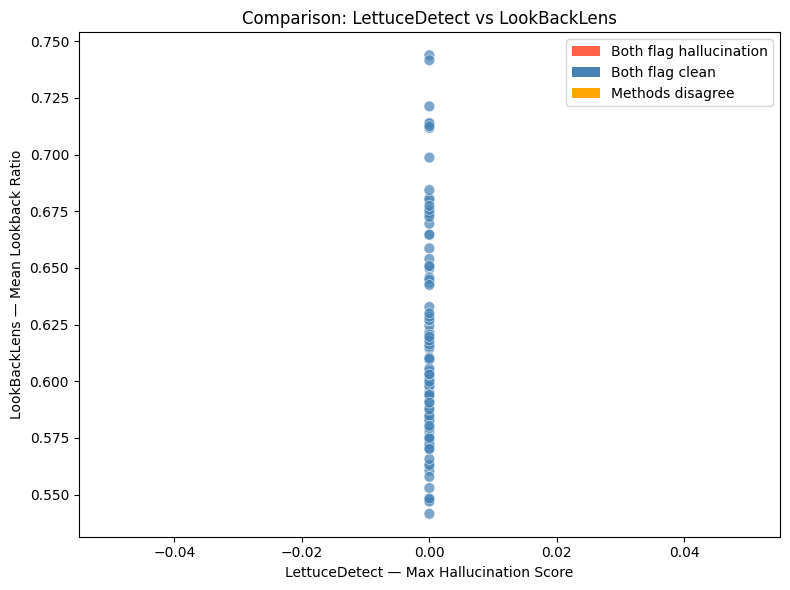

In [78]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = [
    ("tomato" if l and lb else "steelblue" if not l and not lb else "orange")
    for l, lb in zip(comparison["LettuceDetect_flag"], comparison["LookBackLens_flag"])
]
ax.scatter(
    comparison["LettuceDetect_score"],
    comparison["LookBackLens_mean_ratio"],
    c=colors, alpha=0.7, edgecolors="white", linewidths=0.5, s=60,
)
ax.set_xlabel("LettuceDetect — Max Hallucination Score")
ax.set_ylabel("LookBackLens — Mean Lookback Ratio")
ax.set_title("Comparison: LettuceDetect vs LookBackLens")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tomato", label="Both flag hallucination"),
    Patch(facecolor="steelblue", label="Both flag clean"),
    Patch(facecolor="orange", label="Methods disagree"),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

In [79]:
summary = pd.DataFrame({
    "Method": ["LettuceDetect", "LookBackLens"],
    "Type": ["BERT token classification", "LLM attention-based"],
    "Backbone": ["ModernBERT (lettuce-detect-base-v2)", f"GPT-2 (proxy; paper uses Llama-2-7B)"],
    "Evaluated Samples": [len(lettuce_results), len(lbl_results)],
    "Hallucination Rate": [
        f"{sum(r['predicted_hallucination'] for r in lettuce_results)/len(lettuce_results):.1%}",
        f"{sum(r['predicted_hallucination_threshold'] for r in lbl_results)/len(lbl_results):.1%}",
    ],
})
display(summary)

print("""
Notes:
  • LettuceDetect operates purely on the (question, context, answer) text — no GPU needed for inference.
  • LookBackLens requires a forward pass through a causal LM to obtain attention weights.
    Using GPT-2 here is a demonstration; swap MODEL_NAME for Llama-2-7B and the paper's
    pre-trained classifier weights (github.com/amazon-science/lookback-lens) for publication-level results.
  • The dataset currently contains only non-corrupted (clean) responses; apply the corruption
    pipeline from dataset_generation.ipynb to obtain labelled hallucinated samples and compute
    precision / recall / F1.
""")

,Method,Type,Backbone,Evaluated Samples,Hallucination Rate
0,LettuceDetect,BERT token classification,ModernBERT (lettuce-detect-base-v2),100,0.0%
1,LookBackLens,LLM attention-based,GPT-2 (proxy; paper uses Llama-2-7B),100,0.0%



Notes:
  • LettuceDetect operates purely on the (question, context, answer) text — no GPU needed for inference.
  • LookBackLens requires a forward pass through a causal LM to obtain attention weights.
    Using GPT-2 here is a demonstration; swap MODEL_NAME for Llama-2-7B and the paper's
    pre-trained classifier weights (github.com/amazon-science/lookback-lens) for publication-level results.
  • The dataset currently contains only non-corrupted (clean) responses; apply the corruption
    pipeline from dataset_generation.ipynb to obtain labelled hallucinated samples and compute
    precision / recall / F1.

